# Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums, fisher_exact
from skbio.diversity import alpha_diversity
from scipy.stats import mannwhitneyu
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from scipy.spatial.distance import cdist
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.ordination import pcoa
from itertools import combinations
from skbio.stats.distance import permanova
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
from adjustText import adjust_text


In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Set the global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [4]:
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")
    
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    
    ellipse = Ellipse((0, 0),
                      width=ell_radius_x * 2,
                      height=ell_radius_y * 2,
                      facecolor=facecolor,
                      **kwargs)
    
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

def get_significance_label(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

def annotate_within_category_pvalues(ax, long_df, x_col, y_col, hue_col, order, hue_order):
    """
    For each x category (e.g., Bacteria/Fungi/Virus), run Mann–Whitney U between two hue groups (RA vs OA)
    and annotate a bracket + significance label.
    """
    # assumes exactly two groups in hue_order (e.g., ['RA','OA'])
    g1, g2 = hue_order[0], hue_order[1]

    for i, cat in enumerate(order):
        sub = long_df[long_df[x_col] == cat]
        d1 = sub[sub[hue_col] == g1][y_col].dropna()
        d2 = sub[sub[hue_col] == g2][y_col].dropna()

        if len(d1) == 0 or len(d2) == 0:
            sig_label = "na"
            p_value = float("nan")
        else:
            _, p_value = mannwhitneyu(d1, d2, alternative='two-sided')
            sig_label = get_significance_label(p_value)

        # bracket placement
        y_max = sub[y_col].max()
        y = y_max * 1.08
        h = y_max * 0.03 if y_max != 0 else 0.03

        # draw a small bracket centered at category tick
        x_center = i
        x1, x2 = x_center - 0.20, x_center + 0.20
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c='black')
        ax.text(x_center, y + h, sig_label, ha='center', va='bottom', fontsize=7, color='black')

        # optional: print p-values
        print(f"Mann-Whitney U for {cat}: p = {p_value:.4g}")

In [5]:
def get_filtered(df, meta, coef, pval):
    filtered = df[
        (df["metadata"] == meta) & 
        (df["coef"].abs() >= coef) & 
        (df["pval"] < pval)
    ]
    return filtered
def get_taxonomy_dict(hdf_repr, level, level_name):
    tax_dict = {}
    print(f"Getting {level_name} level taxonomy dictionary...")
    for i in hdf_repr["HROM_taxonomy"]:
        try:
            tax = i.split(";")[level]
            spe = i.split(";")[-1]
            tax_dict[spe] = tax
        except:
            continue
    return tax_dict

# Data

In [ ]:
# Load the taxonomy and count matrix files
bacteria_maaslin2 = pd.read_csv("./99_Original_Data/bacteria_maaslin2_output_2.tsv", sep = '\t')
fungi_matrix = pd.read_csv("./01_Processed_Data/fungi_matrix_filtered.tsv", sep='\t', index_col=0)
fungi_matrix_before_filtering = pd.read_csv("./99_Original_Data/fungi_unfiltered_count.tsv", sep='\t', index_col=0).transpose()  # Transpose to have samples as rows
fungi_matrix_before_filtering = fungi_matrix_before_filtering.fillna(0)  # Fill NaN values with 0
fungi_matrix_before_filtering.index = fungi_matrix_before_filtering.index.str.replace('_bracken', '', regex=True)  # Clean sample IDs
virus_matrix = pd.read_csv("./01_Processed_Data/virus_matrix_filtered.tsv", sep='\t', index_col=0)
virus_matrix_before_filtering = pd.read_csv("./99_Original_Data/virus_unfiltered_count.tsv", sep = '\t', index_col=0).transpose()  # Transpose to have samples as rows
virus_matrix_before_filtering = virus_matrix_before_filtering.fillna(0)  # Fill NaN values with 0
metadata = pd.read_csv("./01_Processed_Data/cleaned_metadata_RA.tsv", sep='\t', index_col=0)
fungi_maaslin2 = pd.read_csv("./99_Original_Data/fungi_maaslin2_output.tsv", sep = '\t')
virus_maaslin2 = pd.read_csv("./99_Original_Data/virus_maaslin2_output.tsv", sep = '\t')

# filter fungi and virus maaslin2 results for Responder_Status
fungi_maaslin2 = fungi_maaslin2[fungi_maaslin2['metadata'] == 'Responder_Status']
virus_maaslin2 = virus_maaslin2[virus_maaslin2['metadata'] == 'Responder_Status']

hdf = pd.read_csv("./99_Original_Data//HROV_HOST_PROFILE_VARIANT_LEVEL.tsv", sep="\t")
vmeta = pd.read_csv("./99_Original_Data/HROV_METADATA.tsv", sep="\t")

/tmp/ipykernel_3801161/2484306081.py:19: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  vmeta = pd.read_csv("/nbl/vault5/home/hjkim/2.HROV_FOR_USERS/0.METADATA/HROV_METADATA.tsv", sep="\t")


# Analysis

## Figure 4A

/tmp/ipykernel_3801161/2057930719.py:61: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


Mann-Whitney U for Fungi: p = 0.5341
Mann-Whitney U for Virus: p = 0.1501


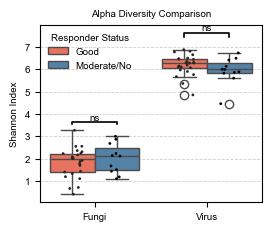

In [21]:
matrices = {'Fungi': fungi_matrix_before_filtering, 'Virus': virus_matrix_before_filtering}

# do TSS for each matrix
for name, mat in matrices.items():
    tss_mat = mat.div(mat.sum(axis=1), axis=0)
    # transpose matrix to have samples as rows and features as columns (skbio convention)
    matrices[name] = tss_mat

# --- 1) Alpha diversity 계산은 기존 그대로 유지 ---
sample_ids = list(matrices['Fungi'].index)

fungal_counts_for_skbio    = matrices['Fungi'].astype(float)
viral_counts_for_skbio     = matrices['Virus'].astype(float)

fungal_shannon_div   = alpha_diversity(metric='shannon', counts=fungal_counts_for_skbio.to_numpy(), ids=sample_ids)
viral_shannon_div    = alpha_diversity(metric='shannon', counts=viral_counts_for_skbio.to_numpy(), ids=sample_ids)

metadata['Fungal Shannon']    = fungal_shannon_div
metadata['Viral Shannon']     = viral_shannon_div

# --- 2) long-form으로 reshape (single plot을 위해 핵심) ---
plot_df = metadata.loc[:, ['Responder_Status', 'Fungal Shannon', 'Viral Shannon']].copy()

hue_order = ['Good', 'Moderate/No']

long_df = plot_df.melt(
    id_vars=['Responder_Status'],
    value_vars=['Fungal Shannon', 'Viral Shannon'],
    var_name='Kingdom',
    value_name='Shannon'
)

# Kingdom 라벨 정리
kingdom_map = {
    'Fungal Shannon': 'Fungi',
    'Viral Shannon': 'Virus'
}
long_df['Kingdom'] = long_df['Kingdom'].map(kingdom_map)

# in long df, map the Responder to Good and Non-Responder to Moderate/No
long_df['Responder_Status'] = long_df['Responder_Status'].map({'Responder': 'Good', 'Non-Responder': 'Moderate/No'})
order = ['Fungi', 'Virus']

# --- 4) Single combined plot: x=Kingdom, hue=diagnosis ---
fig, ax = plt.subplots(figsize=(2.6, 2.2), constrained_layout=True)

custom_palette = ['#FF6347', '#4682B4'] 

sns.boxplot(
    data=long_df,
    x='Kingdom',
    y='Shannon',
    hue='Responder_Status',
    order=order,
    hue_order=hue_order,
    palette=custom_palette,
    ax=ax
)

# 점(개별 샘플): hue를 같이 줘야 dodge가 됨
sns.stripplot(
    data=long_df,
    x='Kingdom',
    y='Shannon',
    hue='Responder_Status',
    order=order,
    hue_order=hue_order,
    dodge=True,
    jitter=0.18,
    size=2,
    color='black',
    ax=ax
)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.xaxis.grid(False)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(hue_order)], labels[:len(hue_order)], title='Responder Status', fontsize=7, title_fontsize=7, frameon=False)

# p-value annotation (Responder vs Non-Responder within each Kingdom)
annotate_within_category_pvalues(
    ax=ax,
    long_df=long_df,
    x_col='Kingdom',
    y_col='Shannon',
    hue_col='Responder_Status',
    order=order,
    hue_order=hue_order
)

ax.set_ylabel('Shannon Index', fontsize=7)
ax.set_xlabel('', fontsize=7)
ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.title('Alpha Diversity Comparison', fontsize=7)
plt.savefig("./03_Output_Figures/Figure_4A.pdf", dpi=300, bbox_inches='tight')
plt.show()


## Figure 4B, Supplementary figure 2

/tmp/ipykernel_3801161/3590772654.py:133: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_xlabel(f'PC1 ({pcoa_results.proportion_explained[0]*100:.2f}% var)', fontsize=7)
/tmp/ipykernel_3801161/3590772654.py:134: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_ylabel(f'PC2 ({pcoa_results.proportion_explained[1]*100:.2f}% var)', fontsize=7)
/tmp/ipykernel_3801161/3590772654.py:133: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]

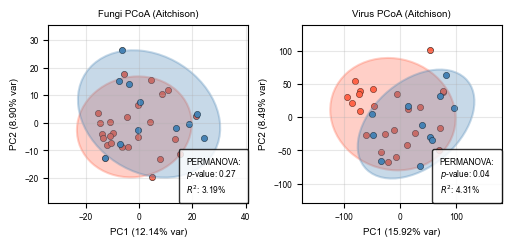

In [22]:
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
from matplotlib.offsetbox import AnchoredText 
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# -------------------------------------------------------------------
# 1. CLR 변환 함수 및 신뢰 타원 함수 정의
# -------------------------------------------------------------------
def clr_transform(X, pseudocount=1e-6):
    """
    Centered log-ratio transform for compositional data (rows = samples).
    """
    X = X.astype(float).clip(lower=0) + pseudocount
    row_sums = X.sum(axis=1).replace(0, np.nan)
    X_rel = X.div(row_sums, axis=0).fillna(pseudocount / X.shape[1])
    logX = np.log(X_rel)
    row_means = logX.mean(axis=1)
    clrX = logX.sub(row_means, axis=0)
    clrX = pd.DataFrame(np.nan_to_num(clrX, nan=0.0, posinf=0.0, neginf=0.0),
                        index=X.index, columns=X.columns)
    clrX = clrX.clip(lower=-50, upper=50)
    return clrX

def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# -------------------------------------------------------------------
# 2. 데이터 준비 및 초기화
# -------------------------------------------------------------------
matrices = {'Fungi': fungi_matrix_before_filtering, 'Virus': virus_matrix_before_filtering}

# 각 매트릭스 TSS 표준화 진행
for name, mat in matrices.items():
    tss_mat = mat.div(mat.sum(axis=1), axis=0)
    matrices[name] = tss_mat

# 메타데이터 중복 인덱스 제거
metadata = metadata[~metadata.index.duplicated(keep='first')]

# 1행 2열 레이아웃 구성
fig, axes = plt.subplots(1, 2, figsize=(5, 2.35), constrained_layout=True)

group_colors = {
    'Good': '#FF6347',        # Tomato
    'Moderate/No': '#4682B4'  # SteelBlue
}

# -------------------------------------------------------------------
# 3. 킹덤별 PCoA 계산 및 시각화 루프
# -------------------------------------------------------------------
for ax, (name, mat) in zip(axes, matrices.items()):
    # [변경] Aitchison Distance 계산 (CLR 변환 후 Euclidean)
    clr_mat = clr_transform(mat)
    aitchison_dist = pdist(clr_mat.values, metric='euclidean')
    distance_matrix = DistanceMatrix(squareform(aitchison_dist), ids=clr_mat.index)

    # [추가] 튜플 에러 방지용 안전한 샘플 정렬 및 매칭
    common_samples = metadata.index.intersection(distance_matrix.ids)
    distance_matrix = distance_matrix.filter(common_samples)
    metadata_sub = metadata.loc[common_samples]

    # 2. 정렬된 데이터를 바탕으로 PERMANOVA 실행
    permanova_results = permanova(distance_matrix, metadata_sub['Responder_Status'], permutations=9999)

    # 3. R² 계산
    n = distance_matrix.shape[0]  
    g = metadata_sub['Responder_Status'].nunique() 
    F_stat = permanova_results['test statistic'] 

    if g > 1 and F_stat > 0:
        denominator_term = (n - g) / ((g - 1) * F_stat)
        r2_calculated = (1 / (1 + denominator_term)) * 100 
    else:
        r2_calculated = np.nan 

    # 4. PCoA 계산 및 메타데이터 결합
    pcoa_results = pcoa(distance_matrix)
    pcoa_df = pcoa_results.samples.iloc[:, :2].copy()
    pcoa_df.columns = ['PC1', 'PC2']
    pcoa_df = pcoa_df.join(metadata_sub)
    
    # 기존 코드의 맵핑 규칙 유지 ('Responder' -> 'Good', 'Non-Responder' -> 'Moderate/No')
    # 만약 원본 데이터가 이미 'Good', 'Moderate/No'라면 이 라인은 무시되거나 에러 없이 넘어갑니다.
    pcoa_df['Responder_Status'] = pcoa_df['Responder_Status'].map({'Responder': 'Good', 'Non-Responder': 'Moderate/No'}).fillna(pcoa_df['Responder_Status'])

    # 5. 그룹별 데이터 플로팅 및 신뢰 타원 그리기
    for status in pcoa_df['Responder_Status'].dropna().unique():
        group_df = pcoa_df[pcoa_df['Responder_Status'] == status]
        color = group_colors.get(status, 'gray') # 만약 대소문자나 그룹명이 다르면 회색으로 표시됨
        
        # 산점도 그리기
        sns.scatterplot(
            data=group_df, x='PC1', y='PC2',
            s=20, color=color, alpha=1, ax=ax, edgecolor='k'
        )
        
        # 제공된 confidence_ellipse 함수를 안전하게 배열(.values) 형태로 전달하여 적용
        if len(group_df) > 2:
            confidence_ellipse(
                group_df['PC1'].values, 
                group_df['PC2'].values, 
                ax,
                n_std=2,  # ~95% CI
                facecolor=color, alpha=0.3, edgecolor=color, linewidth=1.5
            )

    # 세부 디자인 구성
    ax.margins(0.2)
    ax.set_title(f'{name} PCoA (Aitchison)', fontsize=7) # [변경] Title 텍스트 변경
    ax.set_xlabel(f'PC1 ({pcoa_results.proportion_explained[0]*100:.2f}% var)', fontsize=7)
    ax.set_ylabel(f'PC2 ({pcoa_results.proportion_explained[1]*100:.2f}% var)', fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', labelsize=6)
    ax.tick_params(axis='y', labelsize=6)

    # 통계량 텍스트 박스(AnchoredText) 배치
    stats_text = (f"PERMANOVA:\n"
                  f"$p$-value: {permanova_results['p-value']:.2f}\n"
                  f"$R^2$: {r2_calculated:.2f}%")

    at = AnchoredText(stats_text, prop=dict(size=6), frameon=True, loc='lower right')
    at.patch.set_boxstyle("round,pad=0.5,rounding_size=0.2")
    at.patch.set_alpha(0.8)
    ax.add_artist(at)

# [변경] 저장 파일명을 Aitchison으로 변경하여 덮어쓰기 방지
plt.savefig("./03_Output_Figures/Figure_4B-C_Aitchison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figure 4C

/tmp/ipykernel_3831470/1612026340.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nsmallest(top_n_labels, "qval"))
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


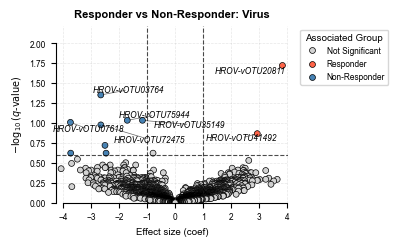

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from adjustText import adjust_text

def draw_virus_volcano_plot(
    virus_maaslin2,
    title="Responder vs Non-Responder: Virus",
    fc_thresh=1.0,
    q_thresh=0.25,
    top_n_labels=5, # 각 그룹(Responder/Non-Responder)별 상위 라벨 개수
    xlim=None,
    ylim=None
):
    # -----------------------------
    # 1. Prepare dataframe
    # -----------------------------
    df = virus_maaslin2.copy()

    if "qval" in df.columns:
        df["qval"] = df["qval"].replace(0, np.nextafter(0, 1))
        df["neg_log10_q"] = -np.log10(df["qval"])
    else:
        raise ValueError("Virus df must contain 'qval' column.")

    # -----------------------------
    # 2. Determine significance & Direction
    # -----------------------------
    # coef가 양수면 Responder, 음수면 Non-Responder로 매핑
    conditions = [
        (df["qval"] < q_thresh) & (df["coef"] > fc_thresh),
        (df["qval"] < q_thresh) & (df["coef"] < -fc_thresh)
    ]
    choices = ["Responder", "Non-Responder"]
    df["Status"] = np.select(conditions, choices, default="Not Significant")

    # -----------------------------
    # 3. Plotting Setup
    # -----------------------------
    if xlim is None:
        xlim = (df["coef"].min() - 0.2, df["coef"].max() + 0.2)

    if ylim is None:
        ylim = (0, df["neg_log10_q"].max() + 0.5)

    plt.figure(figsize=(3, 2.3))

    # PCoA 플롯과 통일성을 주기 위한 색상 팔레트
    custom_palette = {
        "Responder": "#FF6347",        # Tomato (빨강 계열)
        "Non-Responder": "#4682B4",    # SteelBlue (파랑 계열)
        "Not Significant": "lightgray"
    }
    
    # 렌더링 순서 보장 (Not Significant를 먼저 그려서 뒤로 보내고, Significant를 위로 올림)
    hue_order = ["Not Significant", "Responder", "Non-Responder"]

    # -----------------------------
    # 4. Scatter Plot (Seaborn 사용)
    # -----------------------------
    sns.scatterplot(
        data=df,
        x="coef",
        y="neg_log10_q",
        hue="Status",
        hue_order=hue_order,
        palette=custom_palette,
        s=18,               # 점 크기
        alpha=1,
        edgecolor="black",  # 점 테두리 추가
        linewidth=0.5,      # 테두리 두께
        legend="brief"
    )

    # -----------------------------
    # 5. Threshold lines
    # -----------------------------
    plt.axhline(-np.log10(q_thresh), color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    plt.axvline(fc_thresh, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    plt.axvline(-fc_thresh, color="black", linestyle="--", linewidth=0.8, alpha=0.7)

    # -----------------------------
    # 6. Label top significant features
    # -----------------------------
    texts = []
    if "feature" in df.columns:
        sig_df = df[df["Status"] != "Not Significant"]
        
        if not sig_df.empty:
            # Responder와 Non-Responder 각각에서 q-value가 가장 작은 top_n 개 추출
            top_n = (
                sig_df.groupby("Status", group_keys=False)
                .apply(lambda x: x.nsmallest(top_n_labels, "qval"))
            )

            for _, row in top_n.iterrows():
                texts.append(
                    plt.text(
                        row["coef"],
                        row["neg_log10_q"],
                        str(row["feature"]),
                        fontsize=6,
                        ha="center",
                        va="center",
                        fontstyle="italic"  # 미생물 이름이므로 이탤릭체 적용
                    )
                )

            # 텍스트 겹침 방지 처리
            if texts:
                adjust_text(
                    texts,
                    arrowprops=dict(arrowstyle="-", color="black", lw=0.5, alpha=0.6),
                    expand_points=(1.5, 1.5)
                )

    # -----------------------------
    # 7. Final layout
    # -----------------------------
    plt.title(title, fontsize=8, weight="bold")
    plt.xlabel("Effect size (coef)", fontsize=7)
    plt.ylabel(r"$-\log_{10}(q\text{-value})$", fontsize=7)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)
    plt.tick_params(axis='x', labelsize=6)
    plt.tick_params(axis='y', labelsize=6)
    
    # 레전드 정리
    plt.legend(title="Associated Group", loc="upper right", bbox_to_anchor=(1.45, 1), 
               fontsize=6, title_fontsize=7, frameon=True)
    
    sns.despine(trim=True)
    
    # 레전드가 잘리지 않도록 bbox_inches 옵션 유지
    plt.savefig("./03_Output_Figures/Figure_4D_Virus_Volcano.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# Example usage
draw_virus_volcano_plot(
    virus_maaslin2,
    title="Responder vs Non-Responder: Virus",
    fc_thresh=1.0,
    q_thresh=0.25,
    top_n_labels=5 
)

## Supplementary figure 3

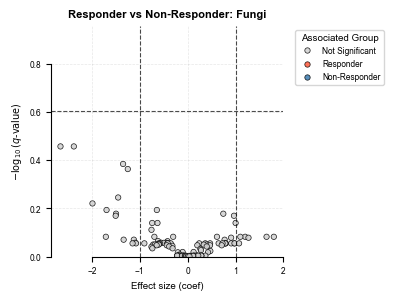

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from adjustText import adjust_text

def draw_fungi_volcano_plot(
    fungi_maaslin2,
    title="Responder vs Non-Responder: Fungi",
    fc_thresh=1.0,
    q_thresh=0.25,
    top_n_labels=5, # 각 그룹(Responder/Non-Responder)별 상위 라벨 개수
    xlim=None,
    ylim=None
):
    # -----------------------------
    # 1. Prepare dataframe
    # -----------------------------
    df = fungi_maaslin2.copy()

    if "qval" in df.columns:
        df["qval"] = df["qval"].replace(0, np.nextafter(0, 1))
        df["neg_log10_q"] = -np.log10(df["qval"])
    else:
        raise ValueError("Fungi df must contain 'qval' column.")

    # -----------------------------
    # 2. Determine significance & Direction
    # -----------------------------
    # coef가 양수면 Responder, 음수면 Non-Responder로 매핑
    conditions = [
        (df["qval"] < q_thresh) & (df["coef"] > fc_thresh),
        (df["qval"] < q_thresh) & (df["coef"] < -fc_thresh)
    ]
    choices = ["Responder", "Non-Responder"]
    df["Status"] = np.select(conditions, choices, default="Not Significant")

    # -----------------------------
    # 3. Plotting Setup
    # -----------------------------
    if xlim is None:
        xlim = (df["coef"].min() - 0.2, df["coef"].max() + 0.2)

    if ylim is None:
        ylim = (0, df["neg_log10_q"].max() + 0.5)

    plt.figure(figsize=(3, 3))

    # PCoA 플롯과 통일성을 주기 위한 색상 팔레트
    custom_palette = {
        "Responder": "#FF6347",        # Tomato (빨강 계열)
        "Non-Responder": "#4682B4",    # SteelBlue (파랑 계열)
        "Not Significant": "lightgray"
    }
    
    # 렌더링 순서 보장 (Not Significant를 먼저 그려서 뒤로 보내고, Significant를 위로 올림)
    hue_order = ["Not Significant", "Responder", "Non-Responder"]

    # -----------------------------
    # 4. Scatter Plot (Seaborn 사용)
    # -----------------------------
    sns.scatterplot(
        data=df,
        x="coef",
        y="neg_log10_q",
        hue="Status",
        hue_order=hue_order,
        palette=custom_palette,
        s=15,               # 점 크기
        alpha=0.9,
        edgecolor="black",  # 점 테두리 추가
        linewidth=0.5,      # 테두리 두께
        legend="brief"
    )

    # -----------------------------
    # 5. Threshold lines
    # -----------------------------
    plt.axhline(-np.log10(q_thresh), color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    plt.axvline(fc_thresh, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    plt.axvline(-fc_thresh, color="black", linestyle="--", linewidth=0.8, alpha=0.7)

    # -----------------------------
    # 6. Label top significant features
    # -----------------------------
    texts = []
    if "feature" in df.columns:
        sig_df = df[df["Status"] != "Not Significant"]
        
        if not sig_df.empty:
            # Responder와 Non-Responder 각각에서 q-value가 가장 작은 top_n 개 추출
            top_n = (
                sig_df.groupby("Status", group_keys=False)
                .apply(lambda x: x.nsmallest(top_n_labels, "qval"))
            )

            for _, row in top_n.iterrows():
                texts.append(
                    plt.text(
                        row["coef"],
                        row["neg_log10_q"],
                        str(row["feature"]),
                        fontsize=6,
                        ha="center",
                        va="center",
                        fontstyle="italic"  # 미생물 이름이므로 이탤릭체 적용
                    )
                )

            # 텍스트 겹침 방지 처리
            if texts:
                adjust_text(
                    texts,
                    arrowprops=dict(arrowstyle="-", color="black", lw=0.5, alpha=0.6),
                    expand_points=(1.5, 1.5)
                )

    # -----------------------------
    # 7. Final layout
    # -----------------------------
    plt.title(title, fontsize=8, weight="bold")
    plt.xlabel("Effect size (coef)", fontsize=7)
    plt.ylabel(r"$-\log_{10}(q\text{-value})$", fontsize=7)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)
    plt.tick_params(axis='x', labelsize=6)
    plt.tick_params(axis='y', labelsize=6)
    
    # 레전드 정리
    plt.legend(title="Associated Group", loc="upper right", bbox_to_anchor=(1.45, 1), 
               fontsize=6, title_fontsize=7, frameon=True)
    
    sns.despine(trim=True)
    
    # 레전드가 잘리지 않도록 bbox_inches 옵션 유지
    plt.savefig("./03_Output_Figures/Figure_4D_Fungi_Volcano.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# Example usage
draw_fungi_volcano_plot(
    fungi_maaslin2,
    title="Responder vs Non-Responder: Fungi",
    fc_thresh=1.0,
    q_thresh=0.25,
    top_n_labels=5 
)

## Figure 4D

/tmp/ipykernel_3831470/64944587.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vmf["idx"] = ["good" if i >=1 else "bad" for i in vmf["coef"]]
/tmp/ipykernel_3831470/64944587.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bmf["idx"] = ["good" if i >=1 else "bad" for i in bmf["coef"]]


Getting genus level taxonomy dictionary...
Getting family level taxonomy dictionary...


/tmp/ipykernel_3831470/64944587.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdf_repr["spe"] = [i.split(";")[-1] for i in hdf_repr["HROM_taxonomy"]]
/tmp/ipykernel_3831470/64944587.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdf_repr["ge"] = [i.split(";")[-2] for i in hdf_repr["HROM_taxonomy"]]


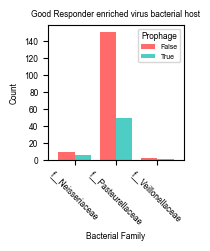

In [10]:
# get filtered species from maaslin2 results
vmf = get_filtered(virus_maaslin2, "Responder_Status", 1, 0.05)
bmf = get_filtered(bacteria_maaslin2, "Responder_Status", 1, 0.05)
# add good/bad idx
vmf["idx"] = ["good" if i >=1 else "bad" for i in vmf["coef"]]
bmf["idx"] = ["good" if i >=1 else "bad" for i in bmf["coef"]]
# get representative viruses from vmeta and extract host information of representative viruses
vmeta_repr = vmeta.loc[vmeta["IsRepresentative"].isin([True])]["Unnamed: 0"].tolist()
hdf_repr = hdf.loc[hdf["Unnamed: 0"].isin(vmeta_repr)]
# get taxonomy dictionaries
s2g = get_taxonomy_dict(hdf_repr, -2, "genus")
s2f = get_taxonomy_dict(hdf_repr, -3, "family")
# species name addition
hdf_repr["spe"] = [i.split(";")[-1] for i in hdf_repr["HROM_taxonomy"]]
# genus name addition
hdf_repr["ge"] = [i.split(";")[-2] for i in hdf_repr["HROM_taxonomy"]]
# set index for merging
hdf_repr = hdf_repr.set_index("Unnamed: 0")
# get good/bad feature lists
vmf_glist = vmf.loc[vmf["idx"].isin(["good"])]["feature"].tolist()
vmf_blist = vmf.loc[vmf["idx"].isin(["bad"])]["feature"].tolist()
bmf_glist = bmf.loc[bmf["idx"].isin(["good"])]["feature"].tolist()
bmf_blist = bmf.loc[bmf["idx"].isin(["bad"])]["feature"].tolist()
# get good/bad virus host info
host_good = hdf_repr.loc[hdf_repr["HROV_vOTU"].isin(vmf_glist)]
host_bad = hdf_repr.loc[hdf_repr["HROV_vOTU"].isin(vmf_blist)]
# split good/bad host info by bacteria responder groups
host_vg_bg = host_good.loc[host_good["spe"].isin(bmf_glist)] 
host_vg_bb = host_good.loc[host_good["spe"].isin(bmf_blist)]
host_vb_bg = host_bad.loc[host_bad["spe"].isin(bmf_glist)]
host_vb_bb = host_bad.loc[host_bad["spe"].isin(bmf_blist)]
# merge with vmeta for more info
cols = ["IsProphage", "Integrase", "Integration_acc","IsIntegrated", "Prophage_by_tools"]
vmeta = vmeta.set_index("Unnamed: 0")
host_vg_bg = host_vg_bg.merge(vmeta[cols], left_index=True, right_index=True, how='left')
host_vg_bb = host_vg_bb.merge(vmeta[cols], left_index=True, right_index=True, how='left')
host_vb_bg = host_vb_bg.merge(vmeta[cols], left_index=True, right_index=True, how='left')
host_vb_bb = host_vb_bb.merge(vmeta[cols], left_index=True, right_index=True, how='left')
# count family level taxonomy in each group
host_vg_bg["family"] = [s2f[i] for i in host_vg_bg["spe"]]
host_vg_bb["family"] = [s2f[i] for i in host_vg_bb["spe"]]
host_vb_bg["family"] = [s2f[i] for i in host_vb_bg["spe"]]
host_vb_bb["family"] = [s2f[i] for i in host_vb_bb["spe"]]
host_vg_bg.groupby(["family", "IsProphage"]).size()
# Create a more informative dataframe for plotting
family_counts = (
    host_vg_bg
    .groupby(["family", "IsProphage"])
    .size()
    .reset_index(name="count")
)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Create figure with better size
fig, ax = plt.subplots(figsize=(1.75, 1.75))

# Pivot for grouped bar plot
family_pivot = (
    family_counts
    .pivot(index="family", columns="IsProphage", values="count")
    .fillna(0)
    .sort_index()
)

# Plot grouped bar chart
family_pivot.plot(
    kind="bar",
    ax=ax,
    color=["#FF6B6B", "#4ECDC4"],
    width=0.8,
)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
ax.set_xlabel("Bacterial Family", fontsize=6)
ax.set_ylabel("Count", fontsize=6)
ax.tick_params(axis="x", labelsize=6, rotation=315)
ax.tick_params(axis="y", labelsize=6)
ax.legend(title="Prophage", title_fontsize=6, fontsize=5)
ax.set_title(
    "Good Responder enriched virus bacterial host",
    fontsize=6)
plt.savefig("./03_Output_Figures/Figure_4E.pdf", dpi=300, bbox_inches='tight')
# # Save figure (note: use fig.savefig, not ax.savefig)
# fig.savefig(
#     "/home/sebin595/project/0.RA_oral_microbiome/for_paper_submission/03_Output_Figures/Figure_3F.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )


## Figure 4E

n = 35
Pearson r = 0.6458
p-value = 2.7904e-05


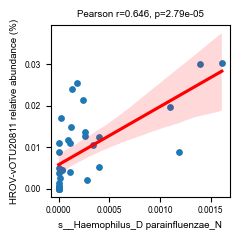

In [11]:
import scipy.stats as stats
from scipy.stats import spearmanr, pearsonr

# Target features
bacteria_feature = "s__Haemophilus_D parainfluenzae_N"
virus_feature = "HROV-vOTU20811"

# Load bacterial abundance table
bacteria_df = pd.read_csv(
    "/home/sebin595/project/0.RA_oral_microbiome/for_paper_submission/01_Processed_Data/bacteria_matrix_rel_abundance_filtered.tsv",
    sep="\t",
    index_col=0
)

# Build sample-wise bacterial series (robust to table orientation)
if bacteria_feature in bacteria_df.columns:
    bacteria_series = bacteria_df[bacteria_feature].copy()  # samples in index
elif bacteria_feature in bacteria_df.index:
    bacteria_series = bacteria_df.loc[bacteria_feature].copy()  # samples in columns -> Series indexed by sample
else:
    raise KeyError(f"{bacteria_feature} not found in bacteria table.")

# Build sample-wise viral series from existing virus_matrix, then convert to relative abundance
if virus_feature in virus_matrix.columns:
    virus_rel = virus_matrix.div(virus_matrix.sum(axis=1), axis=0) * 100  # samples x vOTUs
    virus_series = virus_rel[virus_feature].copy()
elif virus_feature in virus_matrix.index:
    virus_rel = virus_matrix.div(virus_matrix.sum(axis=0), axis=1) * 100  # vOTUs x samples
    virus_series = virus_rel.loc[virus_feature].copy()
else:
    raise KeyError(f"{virus_feature} not found in virus_matrix.")

# Align by common sample IDs
bacteria_series.index = bacteria_series.index.astype(str)
virus_series.index = virus_series.index.astype(str)
common_samples = bacteria_series.index.intersection(virus_series.index)

x = pd.to_numeric(bacteria_series.loc[common_samples], errors="coerce")
y = pd.to_numeric(virus_series.loc[common_samples], errors="coerce")
valid = x.notna() & y.notna()
x, y = x[valid], y[valid]

# Pearson correlation
r, p = pearsonr(x, y)

print(f"n = {len(x)}")
print(f"Pearson r = {r:.4f}")
print(f"p-value = {p:.4e}")

# Optional: quick scatter plot
plt.figure(figsize=(2.5, 2.5))
sns.regplot(x=x, y=y, scatter_kws={"s": 15, "alpha": 1}, line_kws={"color": "red"})
plt.xlabel(bacteria_feature, fontsize=7)
plt.ylabel(f"{virus_feature} relative abundance (%)", fontsize=7)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title(f"Pearson r={r:.3f}, p={p:.2e}", fontsize=7)
plt.tight_layout()
plt.savefig("./03_Output_Figures/Figure_4G.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figure 4F

                                          function  statistic   p_value  \
23              CII-like transcriptional activator   3.251311  0.001149   
19                     Bxa ADP-ribosyl transferase   3.198011  0.001384   
504       tail protein with endopeptidase activity  -3.198011  0.001384   
363                          nuclear shell protein   2.860443  0.004230   
64                       DnaC-like helicase loader  -2.665009  0.007699   
256                                esterase/lipase  -2.665009  0.007699   
359               nicking at origin of replication   2.522875  0.011640   
251  endonuclease V N-glycosylase UV repair enzyme   2.522875  0.011640   
228                       collagen like minor tail   2.505108  0.012241   
124                         ParB C-terminal domain   2.451808  0.014214   
488                                tail completion   2.451808  0.014214   
126                    ParB-like partition protein  -2.416275  0.015680   
422                      

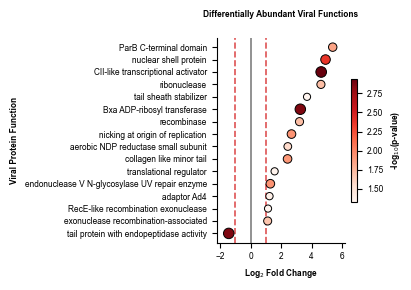

In [12]:
patient_meta = pd.read_csv("/home/sebin595/project/0.RA_oral_microbiome/for_paper_submission/01_Processed_Data/cleaned_metadata_RA.tsv", sep = '\t', index_col=0)

protein_function_count = pd.read_csv('/home/sebin595/project/0.RA_oral_microbiome/3_virus_analysis/9_protein_function/viral_protein_functional_counts.tsv', sep='\t', index_col=0)
protein_function_count.columns = protein_function_count.columns.astype(str)
protein_function_count.index = protein_function_count.index.str.replace('_diamond.tsv', '', regex=True)

# Filter for samples with Responder_Status metadata (index alignment)
common_samples = protein_function_count.index.intersection(patient_meta.index)
responder_samples = common_samples[patient_meta.loc[common_samples, "Responder_Status"].notna()]
protein_function_count = protein_function_count.loc[responder_samples]

# Calculate relative abundance for each sample (handle zero-sum columns)
protein_function_count = protein_function_count.fillna(0)
protein_function_rel_abundance = protein_function_count.div(protein_function_count.sum(axis=0), axis=1) * 100
protein_function_rel_abundance = protein_function_rel_abundance.fillna(0)

# Wilcoxon rank-sum test for each protein function (R vs NR)
from scipy.stats import ranksums
protein_function_stats = []

# Pre-compute Responder_Status mask for current samples (index-aligned)
status_mask = patient_meta.loc[protein_function_rel_abundance.index, "Responder_Status"]
is_responder = status_mask == "Responder"
is_non_responder = status_mask == "Non-Responder"

# 1. FIX: Relative abundance should be calculated across samples (rows), 
# so we divide by the sum of each column (axis=0).
# Note: Usually, abundance is (count / total_counts_in_sample). 
# If samples are columns, sum axis=0. If samples are rows, sum axis=1.
# Based on your .loc[responder_samples], samples are currently your ROWS.
protein_function_rel_abundance = protein_function_count.div(protein_function_count.sum(axis=1), axis=0) * 100
protein_function_rel_abundance = protein_function_rel_abundance.fillna(0)

# 2. FIX: The loop should iterate through columns (functions)
for function in protein_function_rel_abundance.columns:
    # Now, protein_function_rel_abundance[function] is a Series indexed by Sample IDs
    # and is_responder is also indexed by Sample IDs. They align!
    responder_values = protein_function_rel_abundance.loc[is_responder, function].dropna()
    non_responder_values = protein_function_rel_abundance.loc[is_non_responder, function].dropna()
    
    if len(responder_values) > 1 and len(non_responder_values) > 1:
        stat, pvalue = ranksums(responder_values, non_responder_values)
        mean_R = responder_values.mean()
        mean_NR = non_responder_values.mean()
        
        # Avoid division by zero for log2FC
        if mean_R > 0 and mean_NR > 0:
            l2fc = np.log2(mean_R / mean_NR)
        else:
            l2fc = np.inf if mean_R > 0 else (-np.inf if mean_NR > 0 else 0)

        protein_function_stats.append({
            'function': function, 
            'statistic': stat, 
            'p_value': pvalue,
            'mean_Responder': mean_R,
            'mean_NonResponder': mean_NR,
            'log2FC': l2fc
        })

protein_function_stats_df = pd.DataFrame(protein_function_stats)
protein_function_stats_df = protein_function_stats_df.sort_values('p_value')
print(protein_function_stats_df.head(20))

# ---------------------------------------------------------
# 1. Publication-Quality 설정 (논문 투고 시 필수)
# ---------------------------------------------------------
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ---------------------------------------------------------
# 2. 데이터 전처리
# ---------------------------------------------------------
df_plot = protein_function_stats_df.copy()
sig_results = df_plot[df_plot["p_value"] < 0.05].copy()

# 무한대 값 처리 (상하한선 + 여백)
real_vals = sig_results['log2FC'].replace([np.inf, -np.inf], np.nan).dropna()
if not real_vals.empty:
    max_val = real_vals.abs().max()
    sig_results['log2FC'] = sig_results['log2FC'].replace(np.inf, max_val + 0.5)
    sig_results['log2FC'] = sig_results['log2FC'].replace(-np.inf, -(max_val + 0.5))

# Log2FC 기준으로 정렬 (Y축을 Effect Size의 그라데이션에 맞춤)
sig_results = sig_results.sort_values("log2FC", ascending=True)

# Log2FC 기준으로 상하한선 추가 (예: ±1)
sig_results = sig_results[sig_results['log2FC'].abs() > 1]

# ---------------------------------------------------------
# 3. 버블 속성 계산
# ---------------------------------------------------------
sig_results["neg_log_p"] = -np.log10(sig_results["p_value"])
# 시각적 구분이 잘 되도록 버블 사이즈 스케일링 약간 상향 조정
sig_results["bubble_size"] = np.clip(sig_results["neg_log_p"] * 20, 15, 200)

# ---------------------------------------------------------
# 4. 플롯 생성
# ---------------------------------------------------------
# 논문에 적합한 깔끔한 비율로 조정
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# p-value를 색상으로 매핑하므로 순차적(Sequential) 컬러맵인 'Reds' 사용
scatter = ax.scatter(
    x=sig_results["log2FC"],
    y=sig_results["function"],
    s=sig_results["bubble_size"],
    c=sig_results["neg_log_p"],
    cmap="Reds", 
    alpha=1,
    edgecolors="black",
    linewidth=0.7,
    zorder=5
)

# --- 기준선 추가 ---
# 중립 기준선 (0)
ax.axvline(x=0, color="black", linewidth=1.2, linestyle="-", alpha=0.5, zorder=1)

# 요청하신 Log2FC 1 (및 생물학적 대칭인 -1) 기준선 추가
ax.axvline(x=1, color="#D62728", linewidth=1.2, linestyle="--", alpha=0.8, zorder=2)
ax.axvline(x=-1, color="#D62728", linewidth=1.2, linestyle="--", alpha=0.8, zorder=2)

# --- 라벨링 및 포맷팅 ---
ax.set_xlabel(r"Log$_2$ Fold Change", fontsize=6, fontweight="bold")
ax.set_ylabel("Viral Protein Function", fontsize=6, fontweight="bold")
ax.set_title("Differentially Abundant Viral Functions", fontsize=6, fontweight="bold", pad=15)

# 눈금 크기 조정 (가독성 확보)
ax.tick_params(axis='x', labelsize=6)
ax.tick_params(axis='y', labelsize=6)

# 양쪽 끝 버블이 잘리지 않도록 x축 여백(xlim) 넉넉히 확보
plt.xlim(sig_results["log2FC"].min() - 0.8, sig_results["log2FC"].max() + 0.8)

# 컬러바 설정
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.04)
cbar.set_label(r"-log$_{10}$(p-value)", fontsize=6, fontweight="bold")
cbar.ax.tick_params(labelsize=6)

# 논문용 깔끔한 테두리 (위쪽/오른쪽 라인 제거)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("./03_Output_Figures/Figure_4F.pdf", dpi=300, bbox_inches='tight')

plt.show()